In [23]:
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import sys
import os
sys.path.insert(0, os.path.abspath('../../src/'))
# Utility to make plots look nice
from kea.utils.plotting import modify_latex_rc, make_ax_step, pretty_axes
from kea.utils import binning
modify_latex_rc()
modify_latex_rc()

# Use the GPU for computing the SF, ACF, and performing Gaussian convolutions
from kea.utils import set_calculation_mode, set_fitting_mode
set_calculation_mode(use_cpu=False, use_gpu=True)
set_fitting_mode(finite_differences=True)

from kea.simulator import make_field

# Set number of grid points
N = 100_000
# Number of dimensions (two-dimensional)
D = 1
# We have the same number of grid points in each dimension
grid_dims = (N,)*D

# Make the field
field = make_field(grid_dims,
                   spectrum_kwargs={'powerlaw': -5./3., 'cutoff_scale': 2.},
                   spectrum_function='cutoff_powerlaw',
                   seed=1, normalize_output=True)

Set statistic function calculation flags: (<CalculationMode.USE_GPU: 1>,)


In [24]:
# KEA is aware of the physical scale. You can change this scale by providing `phys_dims` to most functions
#   or via changing the default physical scale (which is 2pi)
from kea.utils import geometry
geometry.DEFAULT_PHYS_SCALE = 2.*np.pi

In [25]:
from kea.statistics.spectra import fourier_modal_spectrum
# Directly compute the power spectrum using the fast Fourier transform
kvec, fft_spectrum = fourier_modal_spectrum(field)

/home/mark.bishop/miniconda3/envs/kea/lib/python3.14/site-packages/scipy/stats/_binned_statistic.py:694: RuntimeWarning: Mean of empty slice
  stat = stat_func(np.array(bin_map[i]))


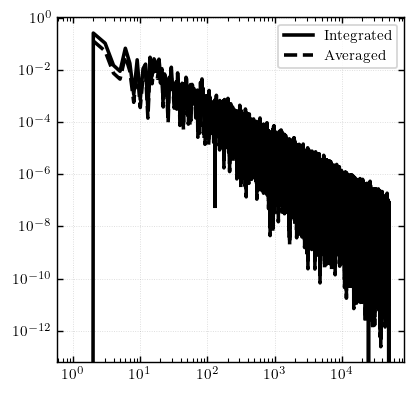

In [26]:
# import the spectrum binning function
from kea.statistics.spectra import bin_spectrum
# Bin to the angle-integrated (integrate over circular shells)
kp_integrated, fek_integrated, p_widths = bin_spectrum(kvec, fft_spectrum, 'integrated')
# Bin to the angle-averaged (average circular shells)
kp_averaged, fek_averaged, kp_bins = bin_spectrum(kvec, fft_spectrum, 'averaged')

## Plot both binned spectra types
fig, ax = plt.subplots(1, 1, figsize=(3.5, 3.5))
ax.plot(kp_integrated, fek_integrated, linestyle='-', color='black', linewidth=2., label='Integrated')
ax.plot(kp_averaged, fek_averaged, linestyle='--', color='black', linewidth=2., label='Averaged')
pretty_axes(ax)
ax.loglog()
ax.legend()

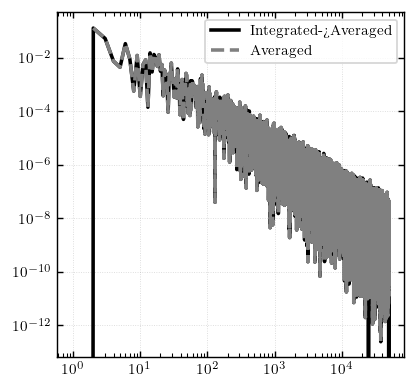

In [27]:
# import helper function to convert
from kea.statistics.spectra import transform_spectrum
# Convert from the integrated spectrum to the averaged spectrum
ki_averaged, feki_averaged = transform_spectrum(kp_integrated, fek_integrated, D, 'integrated', 'averaged', grid_dims, bin_widths=p_widths, is_centered=True)

fig, ax = plt.subplots(1, 1, figsize=(3.5, 3.5))
ax.plot(ki_averaged, feki_averaged, linestyle='-', color='black', linewidth=2., label='Integrated->Averaged')
ax.plot(kp_averaged, fek_averaged, linestyle='--', color='gray', linewidth=2., label='Averaged')
pretty_axes(ax)
ax.loglog()
ax.legend()

In [28]:
from kea.statistics.statfunc import complete_symmetric_correlation_function
from kea.statistics.spectra import bt_modal_spectrum

# First calculate the ACF
lags, acf_full = complete_symmetric_correlation_function(field)
# Compute the correlogram
kvec_bt, bt_spectrum = bt_modal_spectrum(acf_full)

In [29]:
kbt_averaged, fekbt_averaged, _ = bin_spectrum(kvec_bt, bt_spectrum, 'averaged')

/home/mark.bishop/miniconda3/envs/kea/lib/python3.14/site-packages/scipy/stats/_binned_statistic.py:694: RuntimeWarning: Mean of empty slice
  stat = stat_func(np.array(bin_map[i]))


In [30]:
from kea.statistics.statfunc import structure_function
from kea.statistics.spectra import esf_integrated_spectrum
from kea.utils import geometry

dx, dk = geometry.get_dxdk(grid_dims)

# First calculate the structure function
lags, sf2 = structure_function(field)
sf2 = np.reshape(sf2, (N//2,)*D)

Text(0.5, 0, 'Wavenumber')

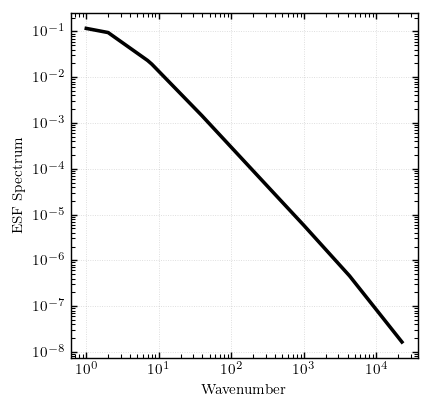

In [31]:
# Convert the lags that describe the grid indices into lags that represent the physical space
physical_lags = np.linalg.norm(lags, axis=1).reshape((N//2,)*D)*dx[0]
# Bin the SF
bins_sf, binned_sf, _ = binning.bin_data(
    physical_lags, sf2, bin_func=np.nanmean, min_bin=dx[0]-dx[0]/2, max_bin=geometry.DEFAULT_PHYS_SCALE/2.,
    cut_excess=True, nan_small=False, ignore_nan=True, bin_loc='center')

from kea.utils import fitting

# Compute the ESF spectrum
ke, biased_esf_spectrum, esf_spectrum = esf_integrated_spectrum(bins_sf, binned_sf, D, sf_subsample_num=8, powerlaw_subsample_num=4, fourier_wavenumbers=kp_integrated)
nyq = np.min([np.pi*N/geometry.DEFAULT_PHYS_SCALE, np.sqrt(2.)*N/geometry.DEFAULT_PHYS_SCALE - dk[0]])
esf_spectrum = esf_spectrum[ke<=nyq]
biased_esf_spectrum = biased_esf_spectrum[ke<=nyq]
ke = ke[ke<=nyq]

ke_averaged, feke_averaged = transform_spectrum(ke, esf_spectrum, D, 'integrated', 'averaged', grid_dims, bin_widths=p_widths[:len(ke)], is_centered=True)

# Plot spectra
fig, ax = plt.subplots(1, 1, figsize=(3.5, 3.5))
ax.plot(ke_averaged, feke_averaged, linestyle='-', color='black', linewidth=2.)
# ax.plot(ke, biased_esf_spectrum, linestyle='--', color='gray', linewidth=2.)
pretty_axes(ax)
ax.loglog()
ax.set_ylabel('ESF Spectrum')
ax.set_xlabel('Wavenumber')

Text(0.5, 0, 'Wavenumber')

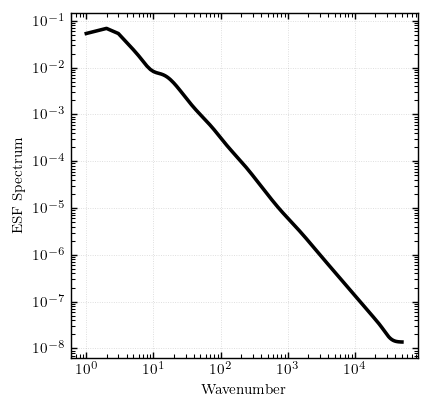

In [32]:
from kea.statistics.spectra import dog_averaged_spectrum
# Directly compute the DoG spectrum using Gaussian convolutions
kd, dog_spectrum = dog_averaged_spectrum(field)

# Plot spectra
fig, ax = plt.subplots(1, 1, figsize=(3.5, 3.5))
ax.plot(kd, dog_spectrum, linestyle='-', color='black', linewidth=2.)
pretty_axes(ax)
ax.loglog()
ax.set_ylabel('ESF Spectrum')
ax.set_xlabel('Wavenumber')

<>:27: SyntaxWarning: "\o" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\o"? A raw string is also an option.
<>:27: SyntaxWarning: "\o" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\o"? A raw string is also an option.
/tmp/ipykernel_39600/451809055.py:27: SyntaxWarning: "\o" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\o"? A raw string is also an option.
  ax.set_xlabel('Frequency, $\omega$')


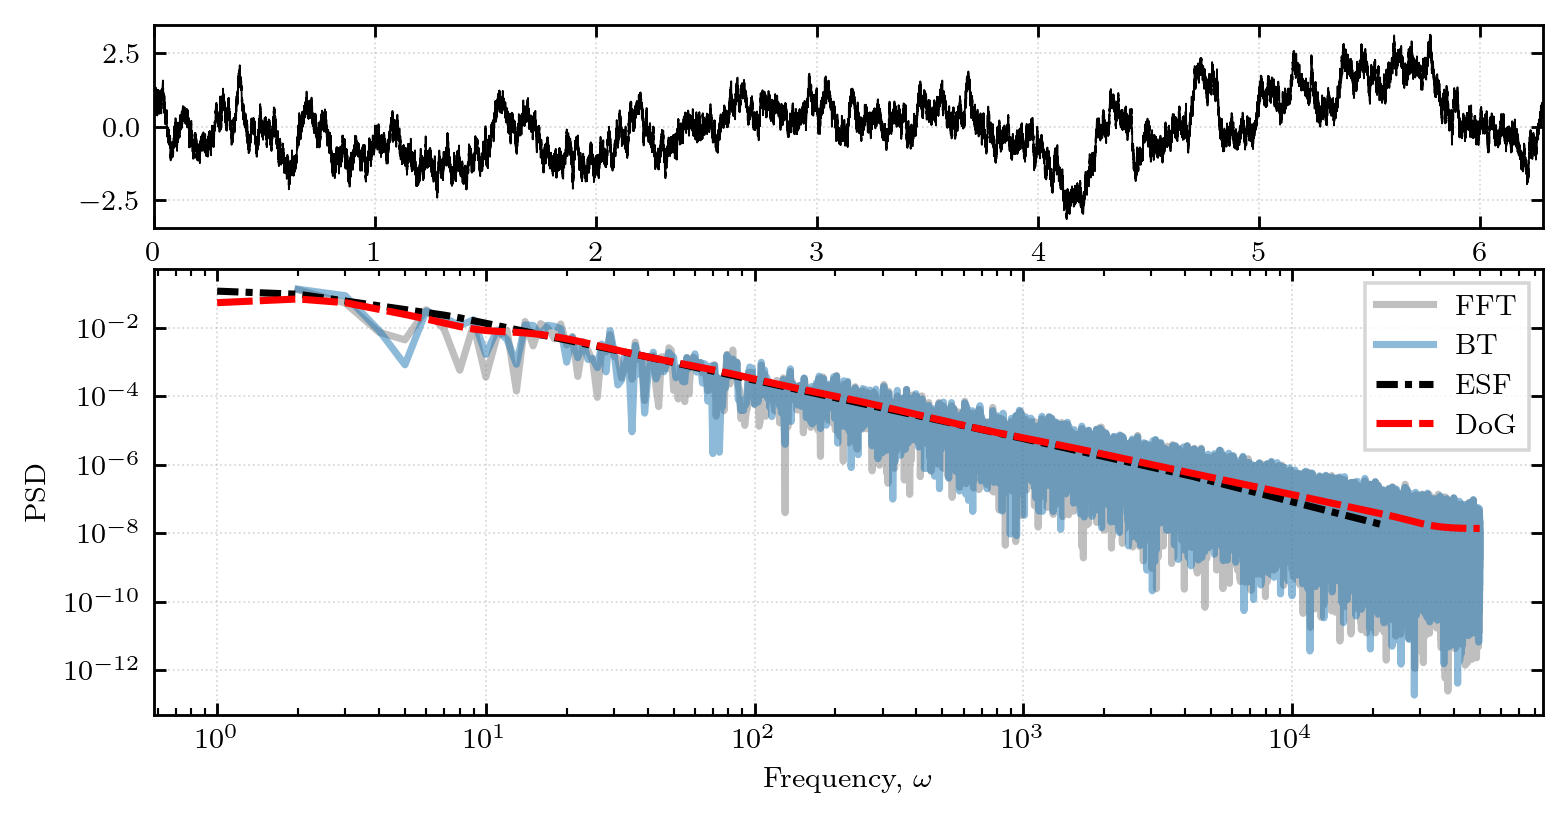

In [41]:

# fig, ax = plt.subplots(1, 1, figsize=(7., 3.5))

grid = '''
AAAA
BBBB
BBBB
'''
fig, axs = plt.subplot_mosaic(grid, dpi=256, figsize=(7., 3.5))

cols = ['black', 'red', 'green', 'blue']
lss = ['-', (0, (3, 1, 1, 1, 1, 1)), (0, (3, 1, 1, 1)), (0, (5, 1))]

ax = axs['A']
ax.plot(np.arange(0,len(field))*dx, field, linestyle='-', color='black', linewidth=0.5)
pretty_axes(ax)
# ax.set_xlim((0, len(field)*dx))
ax.set_xlim((0, 2.*np.pi))

ax = axs['B']
ax.plot(kp_averaged, fek_averaged, linestyle=lss[0], color='gray', linewidth=2., label='FFT', alpha=0.5)
ax.plot(kbt_averaged, fekbt_averaged, linestyle=lss[0], color='tab:blue', linewidth=2., label='BT', alpha=0.5)
ax.plot(ke_averaged, feke_averaged, linestyle=lss[2], color=cols[0], linewidth=2., label='ESF')
ax.plot(kd, dog_spectrum, linestyle=lss[3], color=cols[1], linewidth=2., label='DoG')
pretty_axes(ax)
ax.loglog()
ax.set_ylabel('PSD')
ax.set_xlabel('Frequency, $\omega$')
ax.legend(fancybox=False)

fig.savefig('PSD_example.png', bbox_inches='tight', pad_inches=0.1)
